Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'cart__max_depth': 5, 'cart__min_samples_leaf': 2, 'cart__min_samples_split': 5}

Train F1-score: 0.5052
Test  F1-score: 0.4912

Classification Report (Teste):
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      9379
           1       0.41      0.61      0.49      1728

    accuracy                           0.80     11107
   macro avg       0.67      0.72      0.69     11107
weighted avg       0.84      0.80      0.82     11107

AUC: 0.8251


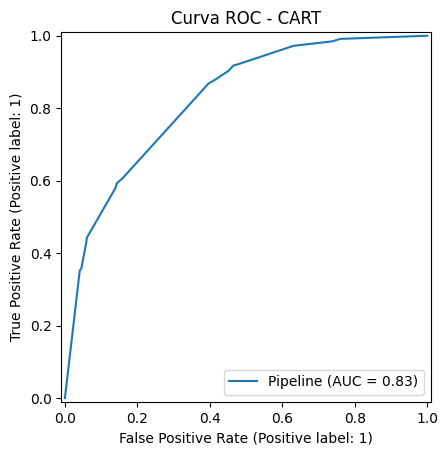

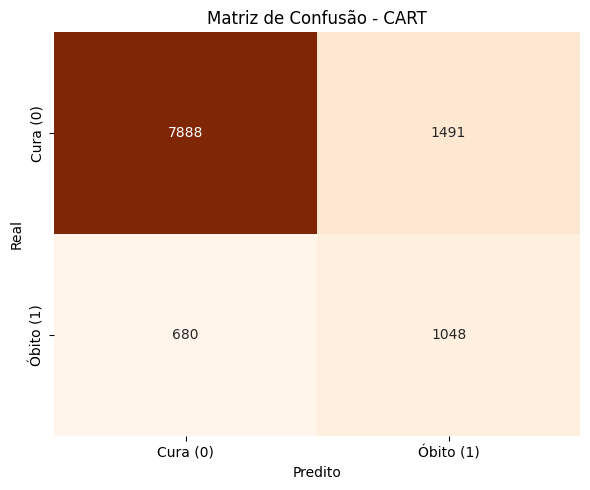

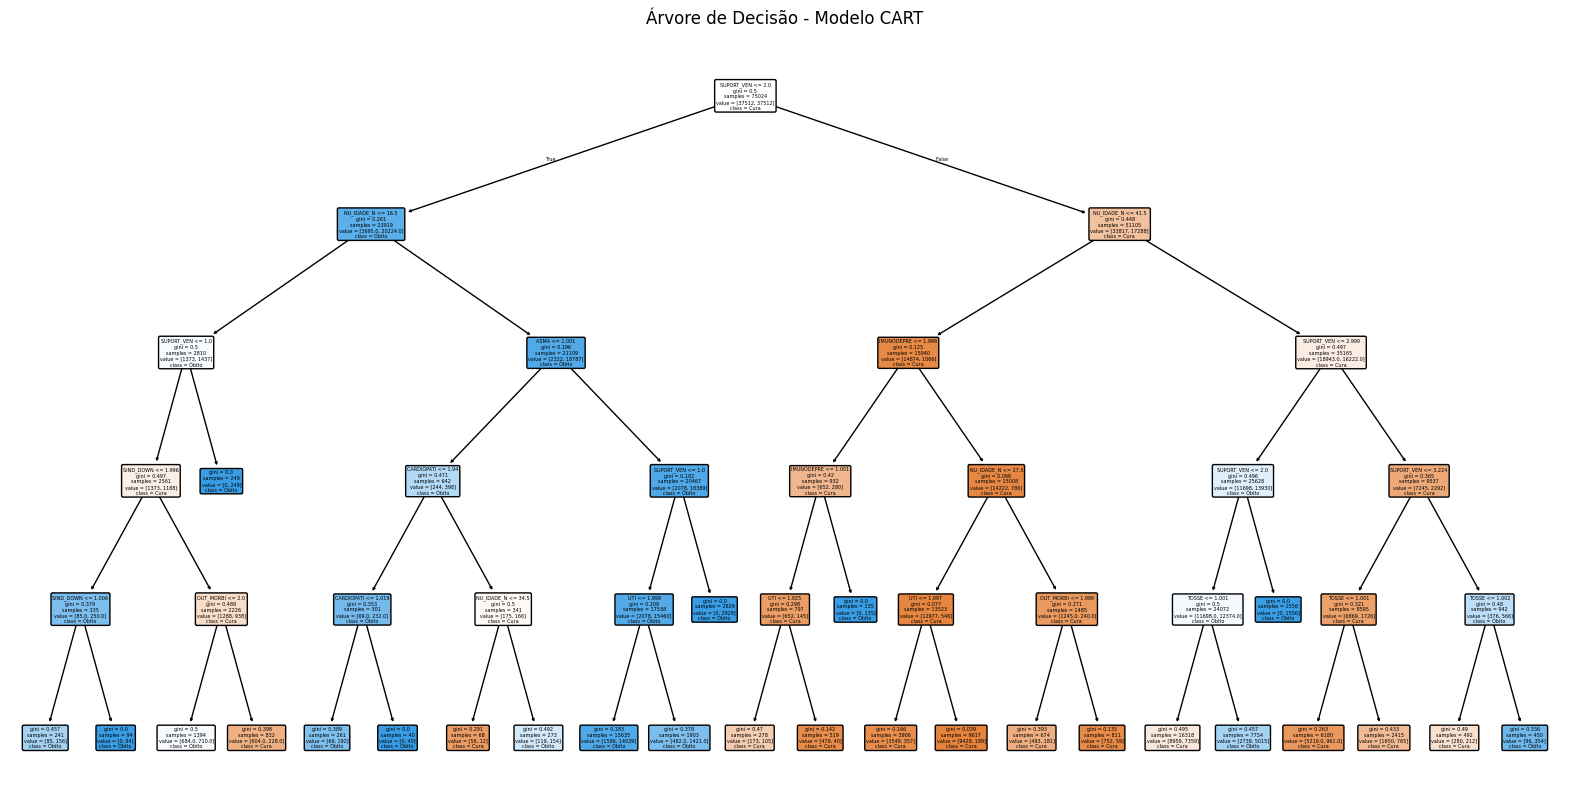

⏱ Tempo total de execução: 22.60 segundos


In [1]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# ⏱ Início do cronômetro
start_time = time.time()

# 📌 2. Carregar os dados
df = pd.read_csv("./INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 📌 3. Pré-processamento
df = df[df['EVOLUCAO'].isin([1, 2])].copy()
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI', 'TOSSE'
]

df[fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')
df['NU_IDADE_N'] = pd.to_numeric(df['NU_IDADE_N'], errors='coerce')
df['CS_SEXO'] = df['CS_SEXO'].map({'M': 0, 'F': 1})
df['SUPORT_VEN'] = pd.to_numeric(df['SUPORT_VEN'], errors='coerce')
df['UTI'] = pd.to_numeric(df['UTI'], errors='coerce')

colunas = fatores_risco + ['NU_IDADE_N', 'CS_SEXO', 'SUPORT_VEN', 'UTI', 'EVOLUCAO']
df.dropna(subset=colunas, inplace=True)

X = df[fatores_risco + ['NU_IDADE_N', 'CS_SEXO', 'SUPORT_VEN', 'UTI']]
y = df['EVOLUCAO']

# 📌 4. Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 📌 5. Pipeline com SMOTE + Decision Tree (CART)
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('cart', DecisionTreeClassifier(random_state=42))
])

# 📌 6. Grade de hiperparâmetros (mais restritos para evitar overfitting)
param_grid = {
    'cart__max_depth': [3, 5, 7],
    'cart__min_samples_split': [5, 10],
    'cart__min_samples_leaf': [2, 4]
}

# 📌 7. GridSearchCV com validação cruzada
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

# 📌 8. Avaliação
model = grid.best_estimator_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print(f"\nTrain F1-score: {f1_score(y_train, y_train_pred):.4f}")
print(f"Test  F1-score: {f1_score(y_test, y_test_pred):.4f}")

# 📌 9. Relatório e AUC
print("\nClassification Report (Teste):")
print(classification_report(y_test, y_test_pred))

print(f"AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

# 📌 10. Curva ROC
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("Curva ROC - CART")
plt.show()

# 📌 11. Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - CART')
plt.tight_layout()
plt.show()

# 📌 12. Plot da Árvore de Decisão (Opcional)
plt.figure(figsize=(20,10))
plot_tree(
    model.named_steps['cart'],
    feature_names=X.columns,
    class_names=['Cura', 'Óbito'],
    filled=True,
    rounded=True
)
plt.title("Árvore de Decisão - Modelo CART")
plt.show()

# ⏱ Tempo de execução
print(f"⏱ Tempo total de execução: {time.time() - start_time:.2f} segundos")


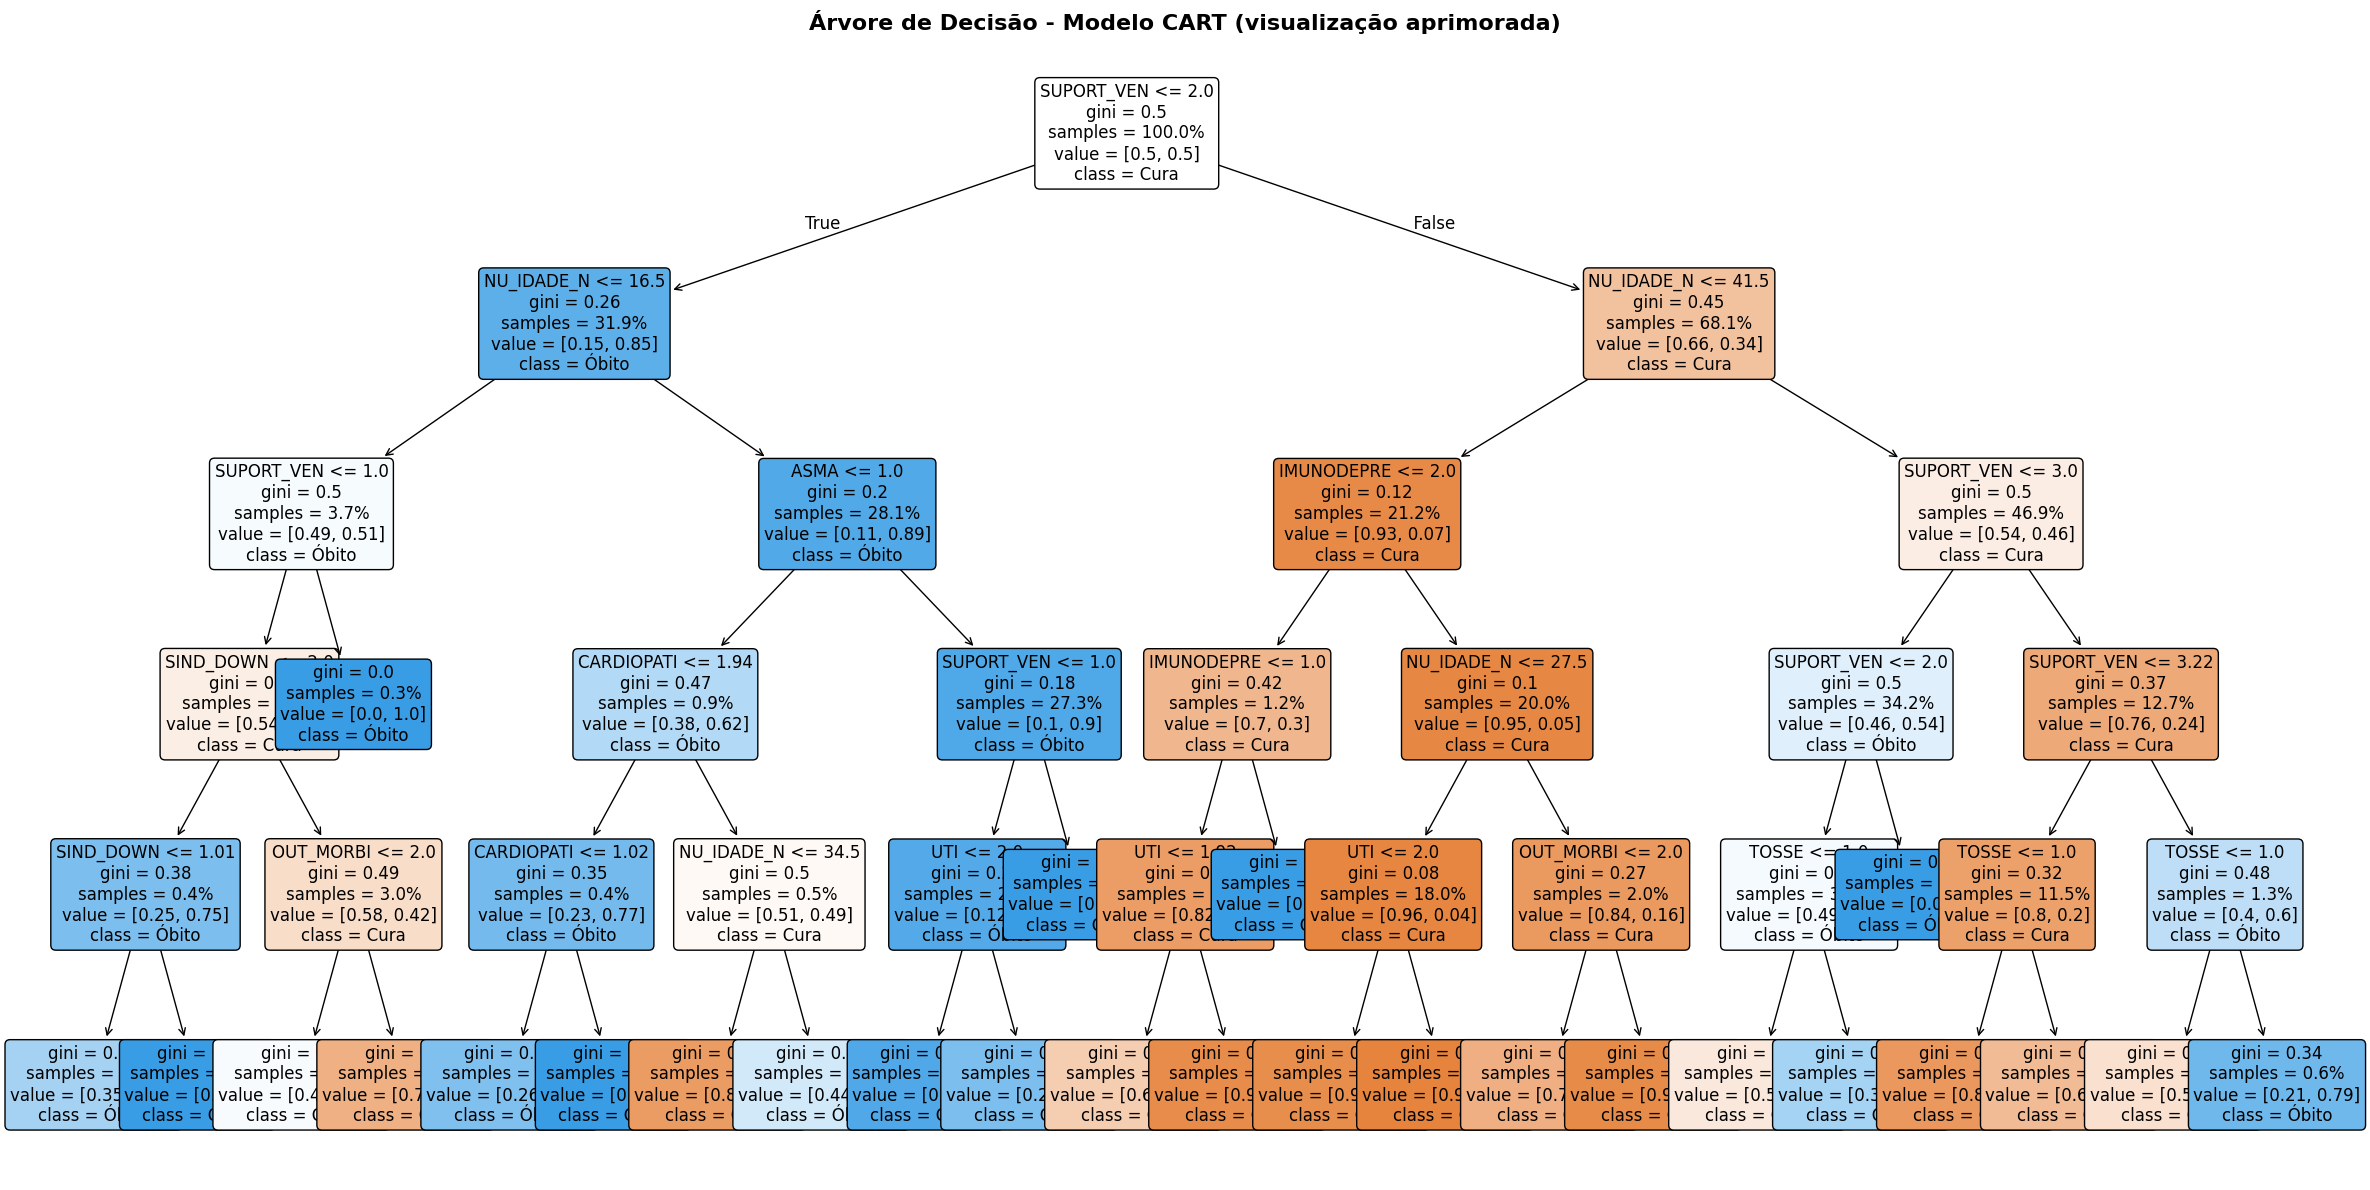

In [2]:
# 📌 12. Plot da Árvore de Decisão (Melhor visualização)
plt.figure(figsize=(24, 12))  # Aumentar o tamanho da figura
plot_tree(
    model.named_steps['cart'],
    feature_names=X.columns,
    class_names=['Cura', 'Óbito'],
    filled=True,
    rounded=True,
    fontsize=12,             # Fonte maior
    impurity=True,           # Mostrar índice de impureza
    proportion=True,         # Proporção em vez de valores absolutos
    precision=2              # Número de casas decimais nos valores
)
plt.title("Árvore de Decisão - Modelo CART (visualização aprimorada)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()
